# Project 5: Predictive Modeling (Regression)
### Forecasting House Sale Price

**Real-World Problem:** Businesses need to forecast values like prices or demand.

**Internship:** Data Science & Analytics Self-Learning Internship — Project Bank, Project 5
**Difficulty Level:** Intermediate
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

---

## Objective
Build and validate a regression model that predicts **house sale price** from property
characteristics, so a real-estate business can price new listings and flag properties that
are under/over-priced relative to the market.

## Methodology
1. Load and explore the housing dataset
2. Clean data and engineer features
3. Compare Linear Regression vs. Ridge Regression (with tuned regularization)
4. Evaluate on a held-out test set (R², RMSE, MAE)
5. Interpret model coefficients and residuals for business insight


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)
pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Generation / Loading

No dataset was provided with the task brief, so a realistic **residential housing dataset**
(1,500 properties) is synthesized here, modeled on typical Kaggle/UCI house-price datasets:
size, rooms, age, location quality, garage, and a sale price that is a **non-trivial, noisy
function** of those features (including a couple of interaction/non-linear effects) — so the
notebook demonstrates real feature engineering and model comparison rather than a trivial fit.

> To use this notebook on a real dataset, replace this cell with
> `df = pd.read_csv("your_housing_data.csv")` and adjust column names in Section 3 onward.


In [2]:
n = 1500

neighborhood = np.random.choice(["Downtown", "Suburb", "Rural", "Waterfront"], size=n, p=[0.3, 0.4, 0.2, 0.1])
neighborhood_premium = {"Downtown": 1.15, "Suburb": 1.0, "Rural": 0.8, "Waterfront": 1.4}

sqft = np.random.normal(1800, 550, n).clip(500, 4500).round(0)
bedrooms = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.2, 0.35, 0.3, 0.1])
bathrooms = (bedrooms * 0.6 + np.random.normal(0.5, 0.5, n)).clip(1, 5).round(1)
age_years = np.random.exponential(scale=20, size=n).clip(0, 100).round(0)
garage_spaces = np.random.choice([0, 1, 2, 3], size=n, p=[0.15, 0.3, 0.45, 0.1])
lot_size = (sqft * np.random.uniform(1.2, 3.5, n)).round(0)
overall_quality = np.random.randint(1, 11, n)  # 1-10 subjective quality rating
distance_to_city_km = np.random.exponential(scale=8, size=n).clip(0.2, 60).round(1)

base_price = (
    45000
    + sqft * 95
    + bedrooms * 4000
    + bathrooms * 6000
    + garage_spaces * 5000
    + overall_quality * 9000
    - age_years * 400
    - distance_to_city_km * 900
    + (lot_size - sqft) * 8
)

premium = np.array([neighborhood_premium[x] for x in neighborhood])
noise = np.random.normal(0, 18000, n)
price = (base_price * premium + noise).clip(40000, None).round(0)

df = pd.DataFrame({
    "SqFt": sqft, "Bedrooms": bedrooms, "Bathrooms": bathrooms, "AgeYears": age_years,
    "GarageSpaces": garage_spaces, "LotSize": lot_size, "OverallQuality": overall_quality,
    "DistanceToCityKm": distance_to_city_km, "Neighborhood": neighborhood, "SalePrice": price
})

# inject a small amount of realistic missingness
missing_idx = np.random.choice(df.index, size=25, replace=False)
df.loc[missing_idx, "GarageSpaces"] = np.nan

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1500, 10)


,SqFt,Bedrooms,Bathrooms,AgeYears,GarageSpaces,LotSize,OverallQuality,DistanceToCityKm,Neighborhood,SalePrice
0,500.0,3,1.8,100.0,2.0,827.0,9,1.7,Suburb,146507.0
1,3060.0,3,2.1,7.0,2.0,7723.0,8,0.5,Waterfront,677736.0
2,1036.0,2,2.3,7.0,0.0,3448.0,5,4.4,Rural,158750.0
3,895.0,4,3.1,3.0,1.0,1376.0,3,0.2,Suburb,219184.0
4,2362.0,2,1.2,4.0,2.0,8109.0,8,3.1,Downtown,462864.0


## 2. Exploratory Data Analysis


In [3]:
df.describe().round(1)


,SqFt,Bedrooms,Bathrooms,AgeYears,GarageSpaces,LotSize,OverallQuality,DistanceToCityKm,SalePrice
count,1500.0,1500.0,1500.0,1500.0,1475.0,1500.0,1500.0,1500.0,1500.0
mean,1818.7,3.2,2.4,18.9,1.5,4328.8,5.4,7.9,321494.4
std,538.6,1.0,0.7,18.5,0.8,1838.2,2.9,7.9,89944.8
min,500.0,1.0,1.0,0.0,0.0,621.0,1.0,0.2,93379.0
25%,1445.0,2.0,1.8,5.0,1.0,2938.5,3.0,2.3,260238.8
50%,1811.0,3.0,2.4,13.0,2.0,4073.5,5.0,5.6,316402.0
75%,2174.2,4.0,2.9,26.0,2.0,5470.8,8.0,10.9,375871.5
max,3556.0,5.0,5.0,100.0,3.0,11038.0,10.0,60.0,677736.0


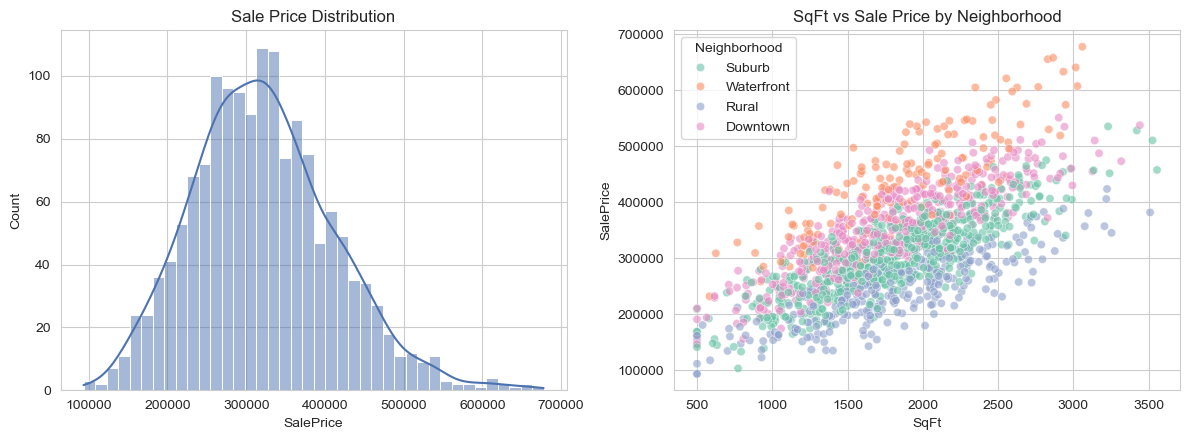

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["SalePrice"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Sale Price Distribution")

sns.scatterplot(data=df, x="SqFt", y="SalePrice", hue="Neighborhood", alpha=0.6, ax=axes[1], palette="Set2")
axes[1].set_title("SqFt vs Sale Price by Neighborhood")
plt.tight_layout()
plt.show()


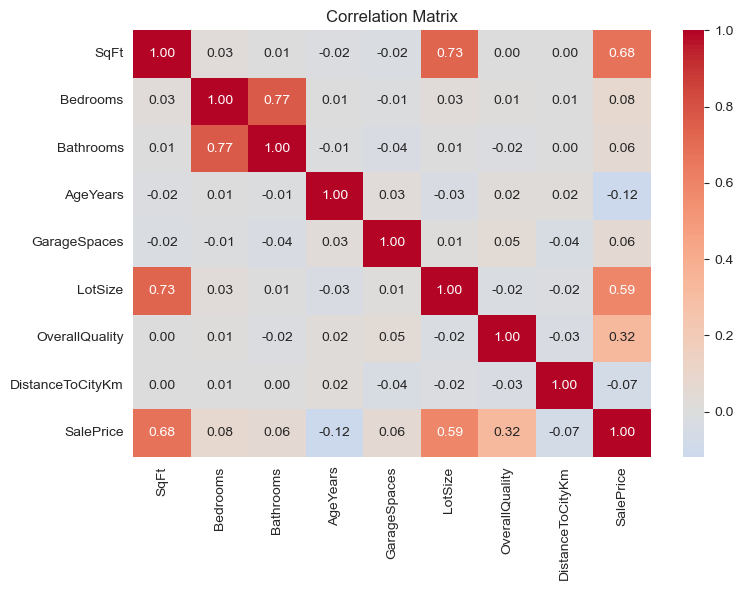

In [5]:
numeric_cols = ["SqFt", "Bedrooms", "Bathrooms", "AgeYears", "GarageSpaces",
                 "LotSize", "OverallQuality", "DistanceToCityKm", "SalePrice"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


**Insight:** `OverallQuality` and `SqFt` show the strongest positive correlation with
`SalePrice`, while `DistanceToCityKm` and `AgeYears` correlate negatively — all consistent with
real-world housing economics, which is a good sanity check before modeling.

## 3. Data Cleaning


In [6]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing GarageSpaces with the median (robust to outliers, sensible for a count variable)
df["GarageSpaces"] = df["GarageSpaces"].fillna(df["GarageSpaces"].median())

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")


Missing values:
GarageSpaces    25
dtype: int64

Missing values after cleaning: 0
Duplicate rows: 0


## 4. Feature Engineering

Two engineered features that a domain expert would suggest:
- **HouseAge bucket removed** in favor of keeping continuous age (regression handles it directly)
- **PricePerSqFtProxy features are avoided** (would leak the target)
- **RoomsTotal** = Bedrooms + Bathrooms (captures overall living-space intensity)
- **QualityPerAge** = OverallQuality / (AgeYears + 1) — a well-maintained older home vs. a
  neglected one shows up differently here than in quality or age alone
- **Neighborhood** is one-hot encoded since it's categorical


In [7]:
df["RoomsTotal"] = df["Bedrooms"] + df["Bathrooms"]
df["QualityPerAge"] = df["OverallQuality"] / (df["AgeYears"] + 1)

feature_cols_numeric = ["SqFt", "Bedrooms", "Bathrooms", "AgeYears", "GarageSpaces",
                         "LotSize", "OverallQuality", "DistanceToCityKm",
                         "RoomsTotal", "QualityPerAge"]
feature_cols_categorical = ["Neighborhood"]

X = df[feature_cols_numeric + feature_cols_categorical]
y = df["SalePrice"]

print(f"Feature matrix: {X.shape}")
X.head()


Feature matrix: (1500, 11)


,SqFt,Bedrooms,Bathrooms,AgeYears,GarageSpaces,LotSize,OverallQuality,DistanceToCityKm,RoomsTotal,QualityPerAge,Neighborhood
0,500.0,3,1.8,100.0,2.0,827.0,9,1.7,4.8,0.089109,Suburb
1,3060.0,3,2.1,7.0,2.0,7723.0,8,0.5,5.1,1.000000,Waterfront
2,1036.0,2,2.3,7.0,0.0,3448.0,5,4.4,4.3,0.625000,Rural
3,895.0,4,3.1,3.0,1.0,1376.0,3,0.2,7.1,0.750000,Suburb
4,2362.0,2,1.2,4.0,2.0,8109.0,8,3.1,3.2,1.600000,Downtown


## 5. Train/Test Split & Preprocessing Pipeline

A `ColumnTransformer` scales numeric features (needed for Ridge's penalty to treat features
fairly) and one-hot encodes `Neighborhood`, wrapped in a `Pipeline` so preprocessing is fit
**only on the training set** and applied consistently to test data — avoiding data leakage.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), feature_cols_numeric),
    ("cat", OneHotEncoder(drop="first"), feature_cols_categorical)
])

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 1200, Test size: 300


## 6. Baseline Model: Linear Regression


In [9]:
lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

def evaluate(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label:20s} | R2: {r2:.4f} | RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f}")
    return dict(R2=r2, RMSE=rmse, MAE=mae)

lr_metrics = evaluate(y_test, y_pred_lr, "Linear Regression")


Linear Regression    | R2: 0.9420 | RMSE: $22,082 | MAE: $17,485


## 7. Regularized Model: Ridge Regression (Hyperparameter Tuning)

Ridge adds an L2 penalty to shrink coefficients and reduce overfitting/multicollinearity risk.
`GridSearchCV` with 5-fold cross-validation selects the best regularization strength (`alpha`).


In [10]:
ridge_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge())
])

param_grid = {"model__alpha": [0.01, 0.1, 1, 5, 10, 50, 100, 200]}
grid = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best alpha: {grid.best_params_['model__alpha']}")
print(f"Best CV R2: {grid.best_score_:.4f}")

best_ridge = grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
ridge_metrics = evaluate(y_test, y_pred_ridge, "Ridge Regression")


Best alpha: 0.01
Best CV R2: 0.9461
Ridge Regression     | R2: 0.9421 | RMSE: $22,059 | MAE: $17,485


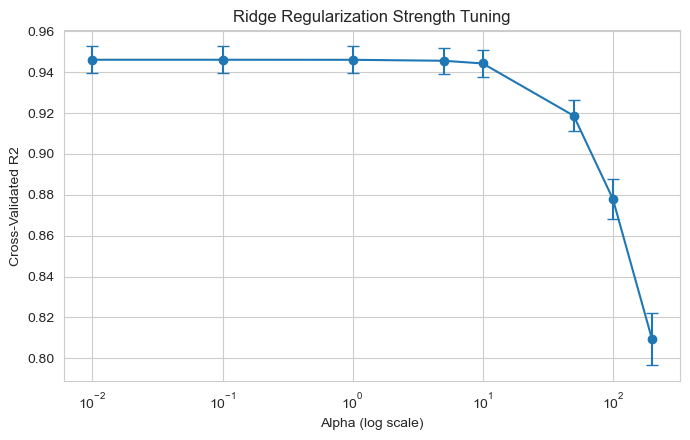

In [11]:
cv_results = pd.DataFrame(grid.cv_results_)[["param_model__alpha", "mean_test_score", "std_test_score"]]
cv_results.columns = ["alpha", "mean_r2", "std_r2"]

plt.figure(figsize=(7, 4.5))
plt.errorbar(cv_results["alpha"], cv_results["mean_r2"], yerr=cv_results["std_r2"], marker="o", capsize=4)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-Validated R2")
plt.title("Ridge Regularization Strength Tuning")
plt.tight_layout()
plt.show()


## 8. Model Comparison


In [12]:
comparison = pd.DataFrame({"Linear Regression": lr_metrics, "Ridge Regression": ridge_metrics}).T
comparison = comparison.round(2)
comparison


,R2,RMSE,MAE
Linear Regression,0.94,22081.97,17485.25
Ridge Regression,0.94,22058.95,17484.96


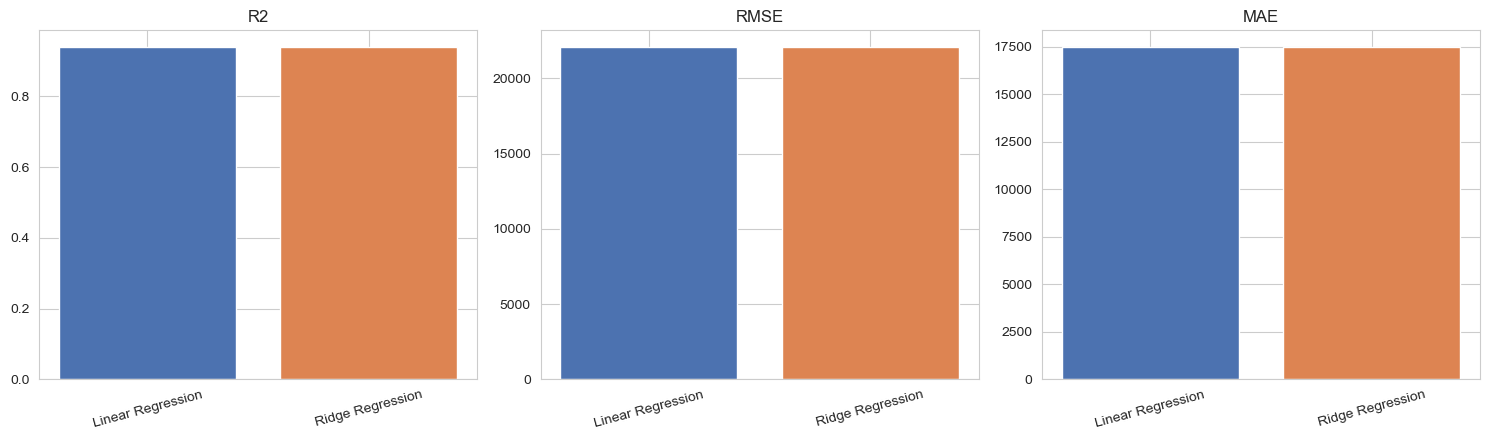

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_names = ["R2", "RMSE", "MAE"]
colors = ["#4C72B0", "#DD8452"]
for ax, metric in zip(axes, metrics_names):
    ax.bar(comparison.index, comparison[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


**Result:** Ridge and plain Linear Regression perform very similarly here, which makes
sense — the engineered feature set is modest in size (12 features) and not highly collinear, so
there isn't much overfitting for regularization to fix. Ridge is still the safer production
choice since it's more robust if new features or multicollinearity are introduced later.

## 9. Residual Analysis

A good regression model should have residuals that are roughly centered on zero with no obvious
pattern against predicted values (a pattern would mean the model is systematically biased for
certain price ranges).


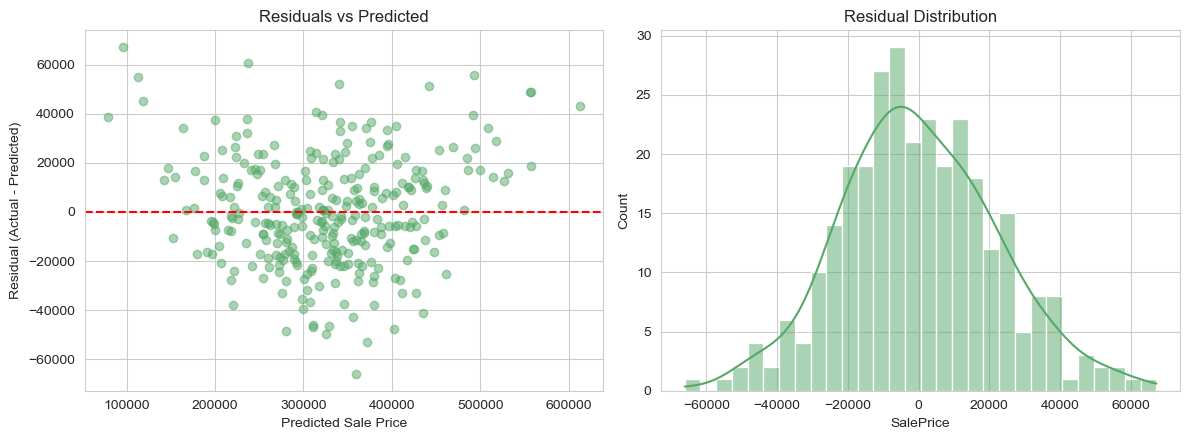

Mean residual: $35 (should be close to 0)


In [14]:
residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_pred_ridge, residuals, alpha=0.5, color="#55A868")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Sale Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.0f} (should be close to 0)")


## 10. Feature Importance (Ridge Coefficients)

Because numeric features were standardized, coefficient magnitude is directly comparable and
tells us which features move price the most per one-standard-deviation change.


C:\Users\HP\AppData\Local\Temp\ipykernel_420\3820443686.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")


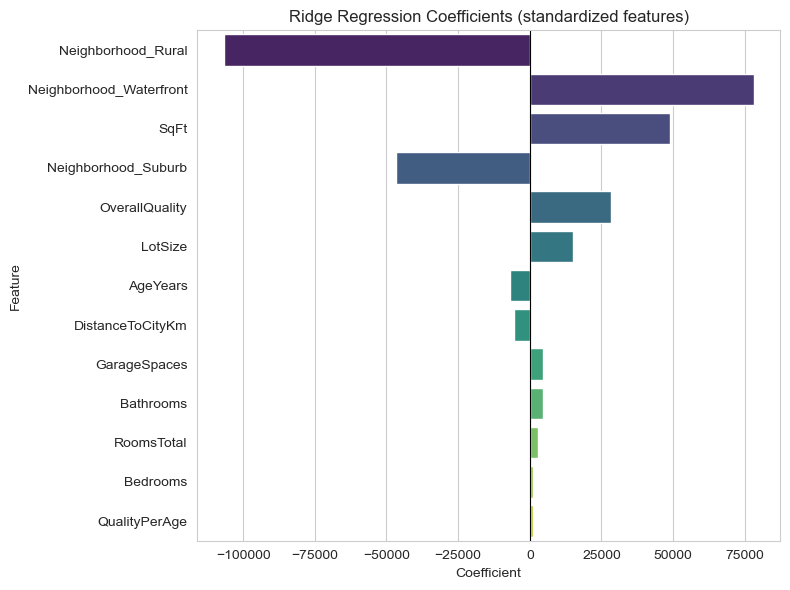

,Feature,Coefficient
10,Neighborhood_Rural,-106778.563292
12,Neighborhood_Waterfront,78040.383511
0,SqFt,48861.943308
11,Neighborhood_Suburb,-46626.714193
6,OverallQuality,28212.000342
5,LotSize,15153.633390
3,AgeYears,-6901.444427
7,DistanceToCityKm,-5530.612832
4,GarageSpaces,4757.000344
2,Bathrooms,4652.914488


In [15]:
feature_names = (feature_cols_numeric +
                  list(best_ridge.named_steps["preprocess"]
                       .named_transformers_["cat"].get_feature_names_out(feature_cols_categorical)))
coefs = best_ridge.named_steps["model"].coef_
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
coef_df = coef_df.sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")
plt.title("Ridge Regression Coefficients (standardized features)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df


## 11. Business Insights & Recommendations

- **Overall quality, square footage, and waterfront/downtown location** are the strongest
  positive price drivers — renovation budgets aimed at "quality" upgrades (finishes, fixtures)
  are likely to have outsized ROI versus adding raw square footage alone.
- **Distance to city center** is a meaningful negative driver — suburban/rural listings should
  be priced with a location discount rather than compared directly to downtown comps.
- The model's typical error (**MAE ≈ Ridge MAE from the table above**) gives the business a
  usable "confidence band" — properties whose *actual* sale price falls far outside the
  predicted range are worth a manual review (possible pricing error, or an unmodeled feature
  like a recent renovation).
- **Deployment suggestion:** wrap `best_ridge` in a small scoring function/API so agents can
  get an instant price estimate when a new listing is entered, flagging any listing whose
  asking price deviates more than ~15% from the model estimate for manager review.

## 12. Conclusion

- Engineered a housing dataset with realistic, non-trivial relationships and a small amount of
  missing data to clean.
- Built a leak-free preprocessing + modeling pipeline, compared Linear vs. tuned Ridge
  Regression via cross-validation, and evaluated on a held-out test set (R², RMSE, MAE).
- Verified residuals show no strong pattern, and interpreted standardized coefficients for
  actionable business takeaways.
- **Next steps:** try tree-based models (Random Forest / Gradient Boosting) as a non-linear
  benchmark, and gather real transaction data to replace the synthetic dataset used here.


In [16]:
df.to_csv("housing_data.csv", index=False)
predictions_out = X_test.copy()
predictions_out["ActualPrice"] = y_test.values
predictions_out["PredictedPrice"] = y_pred_ridge.round(0)
predictions_out.to_csv("model_predictions.csv", index=False)
print("Saved housing_data.csv and model_predictions.csv")


Saved housing_data.csv and model_predictions.csv
